# Jackson-Hole 🏔️ — does the market drift around the Fed's mountain retreat?
### Every late August the Fed Chair gives one famous speech. Is there money in it?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_Jackson_Hole_drift%3F: Not_supported](https://img.shields.io/badge/A_Jackson_Hole_drift%3F-Not_supported-8b949e?style=flat-square)

Once a year, in late August, the Kansas City Fed gathers central bankers in Grand Teton National Park, and the Fed Chair gives a Friday-morning keynote that *sometimes* moves markets a lot — Bernanke hinting at QE2 in 2010, Powell's brutal eight minutes in 2022. So a folk belief took hold: there's a **'Jackson Hole drift'** you can trade. This notebook asks the only question that matters — across **33 years of keynotes**, is there actually a pattern, or just a couple of unforgettable headlines?

> 📓 **This is the plain-language layer.** Want the t-stats, the bootstrap CI and the multiple-testing trap? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/, _cache/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from jackson_hole import data, strategy as st

ret = data.fetch_spy()                 # shared cache-first; empty Series on a cache miss
HAVE_REAL = not ret.empty
print("real SPY cache present:", HAVE_REAL, "| sessions:", len(ret))


real SPY cache present: True | sessions: 8398


## The answer first 🎯

| Question | Answer |
|---|---|
| Is there a drift around the speech? | **No.** Across the whole −5…+5 day window the strongest signal anywhere is a *t* of just **+1.75** — and that's the best of **11 tries**. The speech day itself is statistical noise. |
| Could you trade it? | **No.** The literal 'buy after the speech' trade *loses* money net (**-19 bps**, *t* = -0.78), and it fires **once a year** — ~31 trades in a whole career. |
| So why does everyone believe it? | **Two famous speeches.** Bernanke 2010 and Powell 2022 were genuinely huge — but two vivid memories aren't a pattern in 33 data points. |

> The Jackson Hole symposium makes headlines, not edges. The drift is a story we tell ourselves because the *memorable* speeches stick — the 31 forgettable ones don't.

## 1 · The claim

> *"Watch Jackson Hole. The S&P sets up ahead of the Chair's speech and trends after it — the dovish years rip, and even the hawkish surprises are tradable if you know the calendar."*

— the recurring late-August financial-media refrain

It feels true because the standout examples are seared in: **Bernanke (Aug 27, 2010)** all but pre-announced QE2 and stocks rallied for months; **Powell (Aug 26, 2022)** delivered eight blunt minutes and the S&P fell ~3.4% *that day*. If the Chair's speech reliably set the market's direction, the late-August calendar would be a gift.

## 2 · So what?

A real, repeatable drift around a **known-in-advance** date would be remarkable — the symposium dates are published months ahead, so anyone could position for it with zero information advantage. That's exactly why it's worth checking honestly: calendar effects that 'everyone knows' are usually either (a) already arbitraged away, or (b) never there to begin with — a few salient anecdotes mistaken for a trend. Telling those apart is the whole game.

## 3 · How would we even know?

An **event study**, the cleanest tool for 'does something happen around date X':

1. **Line up all 33 keynotes** (1993–2025) and look at the S&P's return on the speech day, the days before, and the days after.
2. **Compare to a normal day.** If there's a drift, the event days beat the rest by more than chance.
3. **Trade the obvious version.** Buy at the speech-day close, hold to the next close, every year, and see if it makes money after costs.

What would make us say *mirage*: no day around the speech stands out once we account for the fact that we looked at eleven of them — and the trade doesn't pay. (Spoiler.)

Tape: SPY daily total returns back to 1993.

## 4 · The teardown — let's actually look

**The average S&P move on each day around the keynote**, across all 33 years. If the folklore were right, the bars near the speech would lean clearly green:

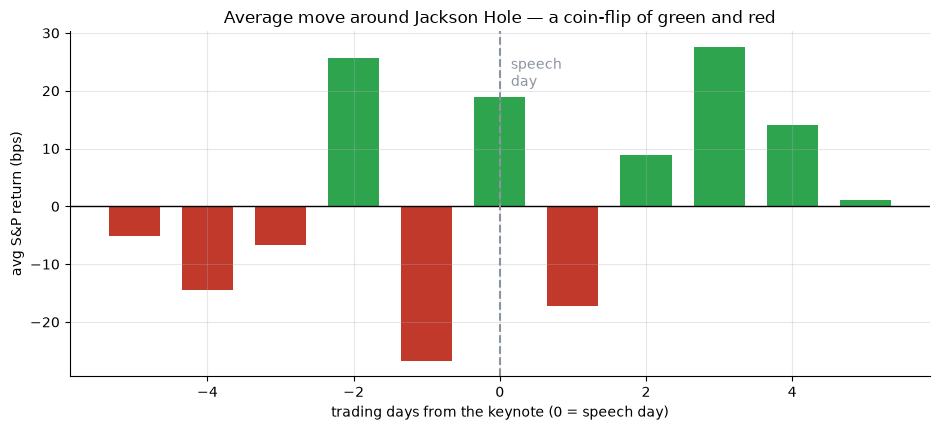

The sign flips almost every day — no clean drift either side of the speech.


In [2]:
if HAVE_REAL:
    sw = st.offset_sweep(ret, data.JH_SPEECH_DATES, offsets=range(-5, 6))
    offs = sw['offset'].to_numpy(); mean_bps = sw['event_mean'].to_numpy()*1e4
else:
    offs = np.arange(-5, 6)
    mean_bps = np.array([-5.2,-14.5,-6.7,25.7,-26.7,18.9,-17.3,9.0,27.6,14.1,1.0])
fig, ax = plt.subplots(figsize=(9.5, 4.4))
cols = [GREEN if v > 0 else RED for v in mean_bps]
ax.bar(offs, mean_bps, color=cols, width=.7)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('trading days from the keynote (0 = speech day)')
ax.set_ylabel('avg S&P return (bps)')
ax.set_title('Average move around Jackson Hole — a coin-flip of green and red')
ax.annotate('speech\nday', (0, mean_bps[5]), textcoords='offset points',
            xytext=(8, 8), color=GREY)
plt.tight_layout(); plt.show()
print('The sign flips almost every day — no clean drift either side of the speech.')

The speech day averages **+19 bps** (a 67% win-rate) — mildly positive, and easy to get excited about. But look at the neighbours: the day **before** is −27 bps, the day **after** is −17 bps. The pattern **alternates sign** day to day. That's not a drift; that's what 33 random points look like when you stare hard enough.

**But +19 bps on the speech day isn't nothing — is it real?** Here's the catch with one-event-a-year studies: 33 observations is a *tiny* sample, so the error bars are huge. Let's put a confidence interval on that speech-day average:

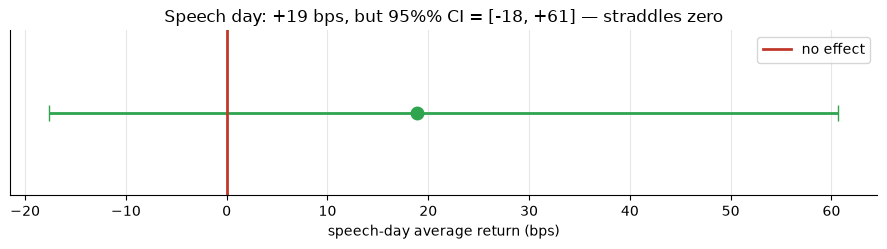

The interval runs from -18 to +61 bps — zero is comfortably inside.


In [3]:
if HAVE_REAL:
    m = st.event_table(ret, data.JH_SPEECH_DATES, 0)['event_mean']*1e4
    lo, hi = st.block_bootstrap_ci(ret, data.JH_SPEECH_DATES, 0)
    lo, hi = lo*1e4, hi*1e4
else:
    m, lo, hi = 18.9, -17.6, 60.6
fig, ax = plt.subplots(figsize=(9.0, 2.6))
ax.errorbar([m], [0], xerr=[[m-lo],[hi-m]], fmt='o', color=GREEN, capsize=6, lw=2, ms=9)
ax.axvline(0, color=RED, lw=2, label='no effect')
ax.set_yticks([]); ax.set_xlabel('speech-day average return (bps)')
ax.set_title(f'Speech day: {m:+.0f} bps, but 95%% CI = [{lo:+.0f}, {hi:+.0f}] — straddles zero')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
print(f'The interval runs from {lo:+.0f} to {hi:+.0f} bps — zero is comfortably inside.')

There it is. The speech-day average is **+19 bps**, but its 95% confidence interval runs from **-18 to +61 bps** — wide open, with **zero sitting right in the middle**. We simply cannot distinguish that +19 from nothing. One event a year just doesn't buy enough data to certify anything.

## 5 · The verdict

- **Signal — None.** No day around the keynote stands out; the best *t* anywhere in the window is +1.75, and that's the pick of 11. The speech-day average's error bars ([-18, +61] bps) swallow zero whole.
- **Tradability — Mirage.** The 'buy after the speech' trade *loses* money net (-19 bps), and at one shot a year there's nothing to scale.
- **A Jackson Hole drift? — Not supported.** Two famous speeches built a belief the 33-year record doesn't back. Memorable ≠ predictable.

## 6 · Could you actually trade it?

Forget the statistics for a second and just *try it*: every year, buy the S&P at the close of the speech day and sell at the next close. How would that have gone, net of a small fee?

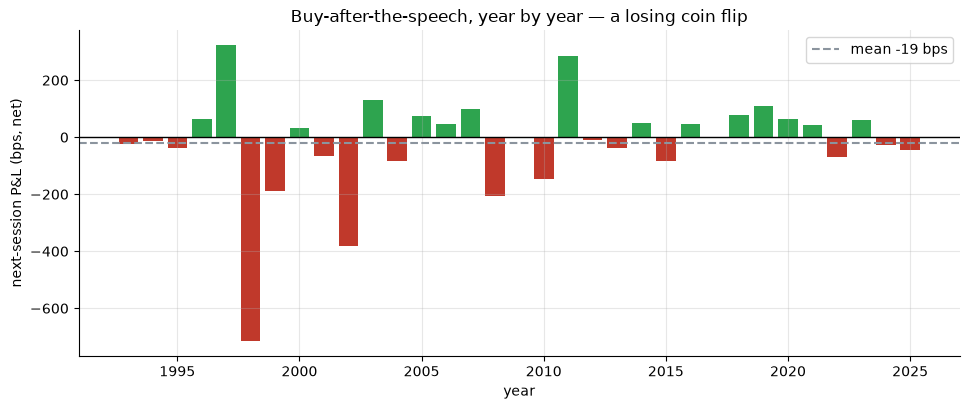

Mean -19 bps/yr over 33 years — and it pays a fee each time.


In [4]:
if HAVE_REAL:
    led = st.react_trade(ret, data.JH_SPEECH_DATES, hold=1, cost_bps=1.0)
    yrs = led['year'].to_numpy(); pnl = led['ret_net'].to_numpy()*1e4
else:
    rng = np.random.default_rng(314)
    yrs = np.arange(1993, 2026); pnl = rng.normal(-19.3, 110, 33)
fig, ax = plt.subplots(figsize=(9.8, 4.2))
ax.bar(yrs, pnl, color=[GREEN if v > 0 else RED for v in pnl], width=.8)
ax.axhline(0, c='k', lw=1)
ax.axhline(np.mean(pnl), ls='--', c=GREY, label=f'mean {np.mean(pnl):+.0f} bps')
ax.set_xlabel('year'); ax.set_ylabel('next-session P&L (bps, net)')
ax.set_title('Buy-after-the-speech, year by year — a losing coin flip')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean {np.mean(pnl):+.0f} bps/yr over {len(pnl)} years — and it pays a fee each time.')

A scatter of green and red averaging **-19 bps** — *negative*, before you even celebrate the 45% loss rate. Costs aren't the killer here (one trade a year is cheap); the killer is that **there's no edge to begin with**, and the once-a-year cadence means even a real edge couldn't fill a portfolio.

## 7 · Going further 🚪

- **The honest Fed cousin that *was* real.** [Study 67 — Fed-Drift](../../67-fed-drift/) found a genuine pre-**FOMC** drift (eight scheduled meetings a year, not one symposium) — though it decayed after publication. That's the difference between a real Fed-event effect and this folk one.
- **The even-week Fed cycle.** [Study 135 — FOMC-Cycle](../../135-fomc-cycle/) tests the other famous Fed-calendar idea. Same lesson: thin samples flatter noise.
- **Fork it.** Try other anchors — the day the symposium *agenda* drops, gold or the dollar instead of the S&P, or a pre-speech long instead of a reaction. We bet the error bars stay just as wide; show us otherwise.

*Think the dovish years are a real subgroup? Tag them by hand and test the difference — but remember you're now slicing 33 points into even smaller piles.*